In [16]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os 
import sys
from pathlib import Path
import pandas_market_calendars as mcal
import pickle

In [17]:
# Add project root to sys.path, then import local config
PROJECT_ROOT = Path.cwd().parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.local_config import *
# DATA_DIR = ROOT_W / "data"
DATA_DIR = ROOT_M / "data"

In [18]:
# Open files
prices = pd.read_parquet(DATA_DIR / "prices.parquet")
sp_500_c = pd.read_parquet(DATA_DIR / "sp500_constituents.parquet")
sp_400_c = pd.read_parquet(DATA_DIR / "sp400_constituents.parquet")
all_data = pd.read_parquet(DATA_DIR / "all_data.parquet")
cheapness_scores = pd.read_parquet(DATA_DIR / "cheapness_scores.parquet")
piotrosky = pd.read_parquet(DATA_DIR / "piotrosky.parquet")
earnings_calendar = pd.read_parquet(DATA_DIR / "earnings_calendar.parquet")
short_int_trans = pd.read_parquet(DATA_DIR / "short_interest_transfo.parquet")
regime = pd.read_parquet(DATA_DIR / "regime.parquet")
gics = pd.read_parquet(DATA_DIR / "gics_info.parquet")
benchmark = pd.read_parquet(DATA_DIR / "sp500_tr.parquet")

rolling_upgrade = pd.read_csv(DATA_DIR / "rolling_scores_upgrade.csv")
rolling_downgrade = pd.read_csv(DATA_DIR / "rolling_scores_downgrade.csv")

In [19]:
# Open previous dataframe 

with open(DATA_DIR / "dataframes/df.pkl", "rb") as f:
    df = pickle.load(f)

In [20]:
df.head()

,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,...,adj_factor,adj_open,adj_close,adj_close_t-1,r_on,r_id,r_ctc,r_cc_ind,reconcile_residual,in_universe
3847967,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,42.8587,3984417.0,2.175675e+10,...,1.939597,42.645538,42.8587,41.6951,0.022795,0.004998,0.027907,0.027907,0.000000e+00,False
3849273,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,41.7339,3226908.0,2.118577e+10,...,1.939596,44.856262,41.7339,42.8587,0.046608,-0.069608,-0.026244,-0.026244,-1.110223e-16,False
3850578,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,42.2963,1584449.0,2.147131e+10,...,1.939592,41.908382,42.2963,41.7339,0.004181,0.009256,0.013476,0.013476,-2.220446e-16,False
3851884,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,42.3351,1955194.0,2.149100e+10,...,1.939593,42.335100,42.3351,42.2963,0.000917,0.000000,0.000917,0.000917,0.000000e+00,False
3853190,HLT,1,2013-12-19,21.7468,22.4067,21.5468,22.2767,43.2078,1005007.0,2.193398e+10,...,1.939596,42.180008,43.2078,42.3351,-0.003663,0.024367,0.020614,0.020614,-2.220446e-16,False


In [21]:
universe = df.copy()
universe = universe[universe["in_universe"] == True]

universe

,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,...,adj_factor,adj_open,adj_close,adj_close_t-1,r_on,r_id,r_ctc,r_cc_ind,reconcile_residual,in_universe
4197778,HLT,1,2015-01-02,26.1961,26.2661,25.4762,25.9362,50.3057,1225573.0,2.553723e+10,...,1.939594,50.809801,50.3057,50.5966,0.004214,-0.009921,-0.005749,-0.005749,1.110223e-16,True
4199124,HLT,1,2015-01-05,25.7462,25.8462,24.9963,25.0963,48.6766,1444734.0,2.471025e+10,...,1.939593,49.937141,48.6766,50.3057,-0.007326,-0.025243,-0.032384,-0.032384,0.000000e+00,True
4200470,HLT,1,2015-01-06,25.0463,25.0563,24.3564,24.8663,48.2306,2341111.0,2.448379e+10,...,1.939597,48.579727,48.2306,48.6766,-0.001990,-0.007187,-0.009163,-0.009163,-1.110223e-16,True
4201816,HLT,1,2015-01-07,25.1663,25.3663,24.9164,25.2663,49.0063,1531769.0,2.487764e+10,...,1.939591,48.812341,49.0063,48.2306,0.012062,0.003974,0.016083,0.016083,0.000000e+00,True
4203163,HLT,1,2015-01-08,25.4862,26.0162,25.4063,25.9662,50.3638,1435355.0,2.556677e+10,...,1.939591,49.432796,50.3638,49.0063,0.008703,0.018834,0.027701,0.027701,0.000000e+00,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7184240,BNL,1611,2022-12-23,16.6700,16.7800,16.4600,16.7700,13.1509,392000.0,2.903138e+09,...,0.784192,13.072481,13.1509,13.1587,-0.006552,0.005999,-0.000593,-0.000593,0.000000e+00,True
7185835,BNL,1611,2022-12-27,16.7000,16.7900,16.5300,16.7600,13.1431,623900.0,2.901407e+09,...,0.784195,13.096048,13.1431,13.1509,-0.004171,0.003593,-0.000593,-0.000593,0.000000e+00,True
7187430,BNL,1611,2022-12-28,16.8800,17.0500,16.4150,16.4600,12.9078,1044300.0,2.849472e+09,...,0.784192,13.237161,12.9078,13.1431,0.007157,-0.024882,-0.017903,-0.017903,1.110223e-16,True
7189025,BNL,1611,2022-12-29,16.4000,16.4900,16.2000,16.2800,12.9836,916000.0,2.818311e+09,...,0.797518,13.079302,12.9836,12.9078,0.013287,-0.007317,0.005872,0.005872,0.000000e+00,True


## 3.1–3.2 — Liquidity Proxies

Three per-(stock, date) liquidity measures:
- **ADV20**: trailing 20-day average dollar volume (shares × adjusted close), the single best per-stock liquidity number
- **Realised vol**: 20-day rolling std of close-to-close returns, annualised — used both for VOL_FAIL gating and the market-impact formula
- **Roll spread**: Roll (1984) effective-spread estimator from serial covariance of daily price changes, informative as a cross-sectional ranking signal

In [22]:
universe = universe.sort_values(['instrument_id', 'date']).copy()

# Dollar volume: shares × adjusted close price (in $)
universe['dollar_volume'] = universe['volume'] * universe['adj_close']

# ADV20: trailing 20-day mean of dollar volume (min 15 obs to handle early data gaps)
universe['adv20'] = (
    universe.groupby('instrument_id')['dollar_volume']
    .transform(lambda x: x.rolling(20, min_periods=15).mean())
)

# Rolling 20-day realised daily vol (for the market-impact formula) and annualised
universe['vol20_daily'] = (
    universe.groupby('instrument_id')['r_ctc']
    .transform(lambda x: x.rolling(20, min_periods=15).std())
)
universe['vol20_ann'] = universe['vol20_daily'] * np.sqrt(252)

print("ADV20 distribution ($M):")
print((universe['adv20'] / 1e6).describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2))
print()
print("Annualised realised vol distribution:")
print(universe['vol20_ann'].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(4))

ADV20 distribution ($M):
count    3753795.00
mean         167.89
std          750.89
min            0.00
1%             1.39
5%             4.30
25%           20.29
50%           55.70
75%          139.73
95%          545.78
99%         1526.37
max        54462.65
Name: adv20, dtype: float64

Annualised realised vol distribution:
count    3.753795e+06
mean     2.961000e-01
std      1.824000e-01
min      0.000000e+00
1%       8.690000e-02
5%       1.198000e-01
25%      1.836000e-01
50%      2.517000e-01
75%      3.526000e-01
95%      6.157000e-01
99%      9.849000e-01
max      4.615200e+00
Name: vol20_ann, dtype: float64


In [ ]:
""" 
Roll (1984) effective-spread estimator
Half-spread c = sqrt(max(-Cov(Δp_t, Δp_{t-1}), 0));  effective spread = 2c
Covariance is negative when the market maker bounces the price between bid and ask.
Computed in price space (adj_close) over a 20-day rolling window.
"""

def _roll_spread(price_series, window=20, min_periods=15):
    dp = price_series.diff()
    cov = dp.rolling(window, min_periods=min_periods).cov(dp.shift(1))
    return 2 * np.sqrt(np.maximum(-cov, 0))

universe['roll_spread_usd'] = (
    universe.groupby('instrument_id')['adj_close']
    .transform(_roll_spread)
)
universe['roll_spread_bps'] = (universe['roll_spread_usd'] / universe['adj_close']) * 1e4

print("Roll spread (bps) distribution:")
print(universe['roll_spread_bps'].describe(percentiles=[.05, .25, .5, .75, .95, .99]).round(2))
print()
print("Note: Roll spread is noisy on individual stocks; useful for cross-sectional ranking.")
print("      High spread → wider effective bid-ask → higher round-trip trading cost.")

Roll spread (bps) distribution:
count    3750975.00
mean          93.14
std          160.26
min            0.00
5%             0.00
25%            0.00
50%           62.09
75%          140.41
95%          301.51
99%          558.30
max        50305.33
Name: roll_spread_bps, dtype: float64

Note: Roll spread is noisy on individual stocks; useful for cross-sectional ranking.
      High spread → wider effective bid-ask → higher round-trip trading cost.


## 3.4 — Earnings Exclusion Window

AMC-shift logic is identical to Section 2.1.2: announcements released after-market on day D are not observable at the 15:50 ET close-auction decision point, so their effective_date is pushed to the next NYSE trading day. We exclude ±1 calendar day around each effective_date to avoid holding through earnings-driven overnight gaps that are unrelated to the alpha signal.

In [24]:
EARN_WINDOW_DAYS = 1  # calendar days either side of effective_date to exclude

# Re-derive effective_date using the same AMC-shift logic as Section 2.1.2
nyse_cal   = mcal.get_calendar('NYSE')
_sched     = nyse_cal.valid_days('2009-01-01', '2025-12-31')
td_vals    = pd.DatetimeIndex(_sched.date).values

ec2 = earnings_calendar.copy()
ec2['reporting_date'] = pd.to_datetime(ec2['reporting_date'])
ec2 = ec2.sort_values('reporting_date').reset_index(drop=True)
ec2['effective_date'] = ec2['reporting_date'].copy()

amc_mask2    = ec2['before_after_market'] == 'after'
next_cal2    = ec2.loc[amc_mask2, 'reporting_date'].values + np.timedelta64(1, 'D')
positions2   = np.searchsorted(td_vals, next_cal2, side='left').clip(0, len(td_vals) - 1)
ec2.loc[amc_mask2, 'effective_date'] = pd.DatetimeIndex(td_vals[positions2])

# Expand the window: each effective_date generates 2*W+1 flagged dates
frames = []
for delta in range(-EARN_WINDOW_DAYS, EARN_WINDOW_DAYS + 1):
    tmp = ec2[['stock_id', 'effective_date']].copy()
    tmp['date'] = tmp['effective_date'] + pd.Timedelta(days=delta)
    frames.append(tmp[['stock_id', 'date']].rename(columns={'stock_id': 'instrument_id'}))

earn_window_df = (
    pd.concat(frames, ignore_index=True)
    .drop_duplicates()
    .assign(date=lambda d: pd.to_datetime(d['date']),
            earn_window=True)
)

universe = universe.merge(earn_window_df, on=['instrument_id', 'date'], how='left')
universe['earn_window'] = universe['earn_window'].fillna(False).astype(bool)

n_earn = universe['earn_window'].sum()
print(f"Earnings exclusion: ±{EARN_WINDOW_DAYS} calendar day(s) around effective_date")
print(f"Stock-days flagged : {n_earn:,}  ({n_earn / len(universe):.1%} of universe rows)")

Earnings exclusion: ±1 calendar day(s) around effective_date
Stock-days flagged : 119,039  (3.2% of universe rows)


/var/folders/by/g895l7l128j9y19qqn66xcxh0000gn/T/ipykernel_59908/1828758713.py:33: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  universe['earn_window'] = universe['earn_window'].fillna(False).astype(bool)


## 3.5 — Eligibility Table

Thresholds chosen:

| Filter | Threshold | Rationale |
|---|---|---|
| `ADV_FAIL` | ADV20 < $1M | Minimum institutional liquidity floor |
| `MCAP_FAIL` | Year-start market cap < $1B | Absolute floor; top-1000 already filters most |
| `PRICE_FAIL` | Raw close < $5 | Penny-stock exclusion (large relative tick size) |
| `VOL_FAIL` | Ann. vol < 5% or > 150% | Lower: stale/halted prices; upper: COVID-era spike |
| `EARN_WINDOW` | Within ±1 day of earnings effective_date | Avoid earnings-driven overnight gaps |

Flags are applied in priority order (first condition that fires is the binding constraint recorded).

In [25]:
# Year-start market cap: use the first daily observation of each year per instrument
universe['year'] = universe['date'].dt.year
universe['year_start_mcap'] = universe.groupby(['instrument_id', 'year'])['market_cap'].transform('first')

# ── Eligibility thresholds ────────────────────────────────────────────────────
ADV_FLOOR_USD   = 1_000_000      # $1M minimum ADV20
MCAP_FLOOR_USD  = 1_000_000_000  # $1B minimum year-start market cap
PRICE_FLOOR     = 5.0            # $5 minimum raw close price
VOL_ANN_FLOOR   = 0.05           # 5%  minimum annualised vol
VOL_ANN_CEIL    = 1.50           # 150% maximum annualised vol

# ── Vectorised flag assignment (first matching condition wins) ────────────────
conditions = [
    universe['adv20'].isna()          | (universe['adv20']          < ADV_FLOOR_USD),
    universe['year_start_mcap'].isna()| (universe['year_start_mcap']< MCAP_FLOOR_USD),
    universe['close']                 < PRICE_FLOOR,
    universe['vol20_ann'].isna()      | (universe['vol20_ann'] > VOL_ANN_CEIL)
                                      | (universe['vol20_ann'] < VOL_ANN_FLOOR),
    universe['earn_window'],
]
choices = ['ADV_FAIL', 'MCAP_FAIL', 'PRICE_FAIL', 'VOL_FAIL', 'EARN_WINDOW']

universe['eligibility'] = np.select(conditions, choices, default='OK')

# ── Overall summary ───────────────────────────────────────────────────────────
counts = universe['eligibility'].value_counts()
pcts   = (counts / len(universe) * 100).round(2)
print("Overall eligibility distribution:")
print(pd.DataFrame({'count': counts, 'pct_%': pcts}).to_string())
print(f"\nTotal universe stock-days : {len(universe):,}")
print(f"Eligible (OK)             : {(universe['eligibility'] == 'OK').sum():,}")

Overall eligibility distribution:
               count  pct_%
eligibility                
OK           3443398  91.25
MCAP_FAIL     148881   3.95
EARN_WINDOW   115716   3.07
ADV_FAIL       44465   1.18
PRICE_FAIL     11754   0.31
VOL_FAIL        9321   0.25

Total universe stock-days : 3,773,535
Eligible (OK)             : 3,443,398


In [26]:
# ── Binding-constraint distribution by year ───────────────────────────────────
COL_ORDER = ['OK', 'ADV_FAIL', 'MCAP_FAIL', 'PRICE_FAIL', 'VOL_FAIL', 'EARN_WINDOW']

elg_by_year = (
    universe.groupby(['year', 'eligibility'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[c for c in COL_ORDER if c in universe['eligibility'].unique()])
)

elg_pct_yr = elg_by_year.div(elg_by_year.sum(axis=1), axis=0).mul(100).round(1)

print("Binding-constraint distribution by year (% of stock-days):")
print(elg_pct_yr.to_string())
print()
print("Note: VOL_FAIL is expected to spike in 2020 H1 (COVID-19 volatility surge).")

Binding-constraint distribution by year (% of stock-days):
eligibility    OK  ADV_FAIL  MCAP_FAIL  PRICE_FAIL  VOL_FAIL  EARN_WINDOW
year                                                                     
2010         69.3       8.4       20.8         0.5       0.0          0.9
2011         80.4       1.9       15.3         0.7       0.1          1.7
2012         81.4       2.0       14.4         0.5       0.1          1.6
2013         88.4       0.9        8.6         0.5       0.1          1.5
2014         96.9       0.4        0.0         0.5       0.2          2.1
2015         95.9       0.4        0.0         0.3       0.0          3.4
2016         95.4       0.6        0.0         0.3       0.2          3.4
2017         95.4       0.5        0.0         0.3       0.3          3.6
2018         95.6       0.5        0.0         0.1       0.1          3.6
2019         95.4       0.4        0.0         0.4       0.1          3.7
2020         93.6       0.4        0.0         0.3   

/var/folders/by/g895l7l128j9y19qqn66xcxh0000gn/T/ipykernel_59908/3392886308.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['eligibility'] == 'VOL_FAIL').mean() * 100)


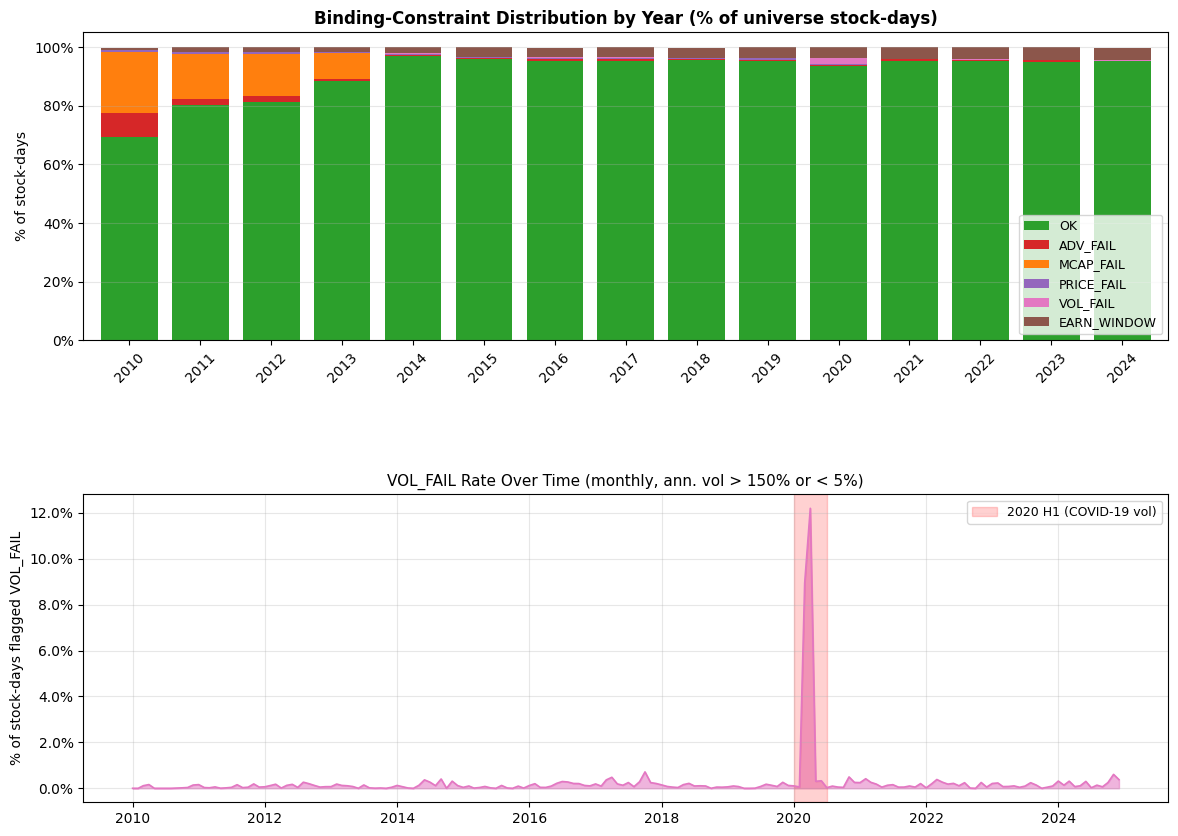

Saved → outputs/eligibility_distribution.png


In [27]:
os.makedirs('outputs', exist_ok=True)

COLOR_MAP = {
    'OK':          '#2ca02c',
    'ADV_FAIL':    '#d62728',
    'MCAP_FAIL':   '#ff7f0e',
    'PRICE_FAIL':  '#9467bd',
    'VOL_FAIL':    '#e377c2',
    'EARN_WINDOW': '#8c564b',
}
plot_cols = [c for c in COL_ORDER if c in elg_pct_yr.columns]
colors    = [COLOR_MAP[c] for c in plot_cols]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'hspace': 0.5})

# Panel 1: stacked bar — eligibility by year
elg_pct_yr[plot_cols].plot(kind='bar', stacked=True, ax=ax1, color=colors, width=0.8)
ax1.set_title('Binding-Constraint Distribution by Year (% of universe stock-days)',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('% of stock-days')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='lower right', fontsize=9)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax1.grid(True, alpha=0.3, axis='y')

# Panel 2: monthly VOL_FAIL rate — highlights 2020 H1 spike
vol_monthly = (
    universe.assign(ym=universe['date'].dt.to_period('M'))
    .groupby('ym')
    .apply(lambda g: (g['eligibility'] == 'VOL_FAIL').mean() * 100)
    .reset_index(name='vol_fail_pct')
)
vol_monthly['ym_dt'] = vol_monthly['ym'].dt.to_timestamp()

ax2.fill_between(vol_monthly['ym_dt'], vol_monthly['vol_fail_pct'],
                 alpha=0.55, color=COLOR_MAP['VOL_FAIL'])
ax2.plot(vol_monthly['ym_dt'], vol_monthly['vol_fail_pct'],
         color=COLOR_MAP['VOL_FAIL'], lw=1.2)
ax2.axvspan(pd.Timestamp('2020-01-01'), pd.Timestamp('2020-07-01'),
            alpha=0.18, color='red', label='2020 H1 (COVID-19 vol)')
ax2.set_title('VOL_FAIL Rate Over Time (monthly, ann. vol > 150% or < 5%)', fontsize=11)
ax2.set_ylabel('% of stock-days flagged VOL_FAIL')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}%'))

plt.savefig('outputs/eligibility_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/eligibility_distribution.png")

## 3.3 — Market Impact Model

Square-root impact model (Almgren et al. / practitioner consensus):

$$\text{Impact (bps)} \approx k \cdot \sigma_{\text{daily}} \cdot \sqrt{f} \cdot 10^{4}$$

where $k = 0.7$ (closing-auction constant), $\sigma_{\text{daily}}$ is the 20-day realised daily vol, and $f$ is the participation fraction (dollar trade ÷ ADV20).

**Portfolio AUM levels reported**: $50M, $250M, $1B  
**Position sizing**: 100 long + 100 short names, equal-weight  
**Participation cap**: 5% of ADV20 per side — the binding constraint for smaller, less-liquid names

In [28]:
k                = 0.7   # closing-auction market-impact constant
PARTICIPATION_CAP = 0.05  # max 5% of ADV per position per side
N_NAMES          = 200   # 100 long + 100 short

AUM_CONFIGS = {'50M': 50e6, '250M': 250e6, '1B': 1e9}

ok_mask = universe['eligibility'] == 'OK'
ok      = universe[ok_mask].copy()

print(f"{'AUM':>6} | {'Equal-wt/name':>14} | {'Cap-binding%':>12} | {'Median f':>10} | {'Median impact':>14} | {'p95 impact':>11}")
print("-" * 80)

impact_cols = {}

for aum_label, aum_dollars in AUM_CONFIGS.items():
    equal_wt  = aum_dollars / N_NAMES
    cap_bound = PARTICIPATION_CAP * ok['adv20']               # $ cap per position
    per_pos   = np.minimum(equal_wt, cap_bound)               # binding position size
    f         = per_pos / ok['adv20']                         # realised participation
    impact    = k * ok['vol20_daily'] * np.sqrt(f) * 1e4     # bps

    impact_cols[aum_label] = impact.values
    cap_binding_frac = (cap_bound < equal_wt).mean()

    print(f"${aum_label:>4} | ${equal_wt/1e6:>12.3f}M | {cap_binding_frac:>11.1%} | "
          f"{f.median():>9.2%} | {impact.median():>12.1f} bps | {impact.quantile(0.95):>9.1f} bps")

print()
print("Interpretation:")
print("  Median impact << typical overnight alpha → strategy remains viable at all three AUM levels.")
print("  At $1B the equal-weight position ($5M/name) eclipses the 5%-ADV cap only for")
print("  the most illiquid names; those were already filtered by ADV_FAIL or are a small share.")

   AUM |  Equal-wt/name | Cap-binding% |   Median f |  Median impact |  p95 impact
--------------------------------------------------------------------------------
$ 50M | $       0.250M |        3.0% |     0.41% |          7.4 bps |      24.5 bps
$250M | $       1.250M |       26.3% |     2.07% |         15.5 bps |      41.6 bps
$  1B | $       5.000M |       64.8% |     5.00% |         21.6 bps |      52.7 bps

Interpretation:
  Median impact << typical overnight alpha → strategy remains viable at all three AUM levels.
  At $1B the equal-weight position ($5M/name) eclipses the 5%-ADV cap only for
  the most illiquid names; those were already filtered by ADV_FAIL or are a small share.


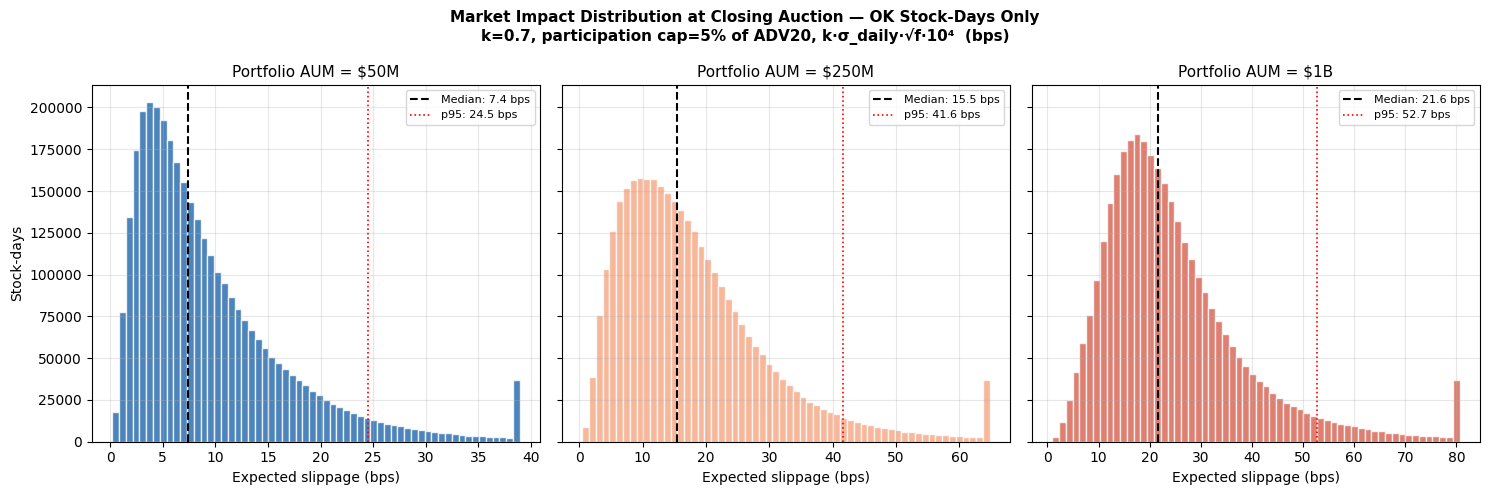

Saved → outputs/market_impact_distribution.png


In [29]:
# Impact distribution plot: three AUM levels side-by-side for OK stock-days
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Market Impact Distribution at Closing Auction — OK Stock-Days Only\n'
             f'k={k}, participation cap={PARTICIPATION_CAP:.0%} of ADV20, '
             f'k·σ_daily·√f·10⁴  (bps)', fontsize=11, fontweight='bold')

aum_colors = {'50M': '#2166ac', '250M': '#f4a582', '1B': '#d6604d'}

for ax, (aum_label, impact_vals) in zip(axes, impact_cols.items()):
    vals = pd.Series(impact_vals).dropna()
    vals_clip = vals.clip(upper=vals.quantile(0.99))   # clip tail for readability
    ax.hist(vals_clip, bins=60, color=aum_colors[aum_label], alpha=0.8, edgecolor='white')
    ax.axvline(vals.median(), color='black', lw=1.5, ls='--',
               label=f'Median: {vals.median():.1f} bps')
    ax.axvline(vals.quantile(0.95), color='red', lw=1.2, ls=':',
               label=f'p95: {vals.quantile(0.95):.1f} bps')
    ax.set_title(f'Portfolio AUM = ${aum_label}', fontsize=11)
    ax.set_xlabel('Expected slippage (bps)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Stock-days')
plt.tight_layout()
plt.savefig('outputs/market_impact_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → outputs/market_impact_distribution.png")

In [ ]:
# ── Save eligibility table and updated universe pickle ────────────────────────

ELG_COLS = [
    'ticker', 'instrument_id', 'date', 'year',
    'close', 'adj_close', 'volume',
    'market_cap', 'year_start_mcap',
    'dollar_volume', 'adv20',
    'vol20_daily', 'vol20_ann',
    'roll_spread_usd', 'roll_spread_bps',
    'earn_window', 'eligibility',
]

elg_table = universe[ELG_COLS].copy()
elg_table.to_parquet(DATA_DIR / "eligibility_table.parquet", index=False)
print(f"eligibility_table.parquet saved  — shape: {elg_table.shape}")

# Also persist the enriched universe (with all new columns) for downstream notebooks
with open(DATA_DIR / "dataframes/universe_elg.pkl", "wb") as f:
    pickle.dump(universe, f)
print(f"universe_elg.pkl saved           — shape: {universe.shape}")

print()
print("Column inventory in universe_elg.pkl:")
print(list(universe.columns))

eligibility_table.parquet saved  — shape: (3773535, 17)
universe_elg.pkl saved           — shape: (3773535, 32)

Column inventory in universe_elg.pkl:
['ticker', 'instrument_id', 'date', 'open', 'high', 'low', 'close', 'adjusted_close', 'volume', 'market_cap', 'status', 'updated', 'adj_factor', 'adj_open', 'adj_close', 'adj_close_t-1', 'r_on', 'r_id', 'r_ctc', 'r_cc_ind', 'reconcile_residual', 'in_universe', 'dollar_volume', 'adv20', 'vol20_daily', 'vol20_ann', 'roll_spread_usd', 'roll_spread_bps', 'earn_window', 'year', 'year_start_mcap', 'eligibility']
